# Airport Network Analysis — Geographic Visualisation

This notebook maps airport locations and highlights the geographical distribution of global hubs.

In [5]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path('../src').resolve()))
from graph_builder import build_graph

G = build_graph('../Data')

## 1. Airport locations

Longitude and latitude coordinates make it possible to inspect the spatial coverage of the network without relying on an external map service.

In [6]:
airport_map = pd.DataFrame([
    {
        'airport_id': node, 'name': data['name'], 'country': data['country'],
        'latitude': data['latitude'], 'longitude': data['longitude'], 'degree': G.degree(node)
    }
    for node, data in G.nodes(data=True)
])
airport_map[['latitude', 'longitude']] = airport_map[['latitude', 'longitude']].apply(pd.to_numeric, errors='coerce')
airport_map = airport_map.dropna(subset=['latitude', 'longitude'])
airport_map.head()

,airport_id,name,country,latitude,longitude,degree
0,1,Goroka Airport,Papua New Guinea,-6.081690,145.391998,8
1,2,Madang Airport,Papua New Guinea,-5.207080,145.789001,14
2,3,Mount Hagen Kagamuga Airport,Papua New Guinea,-5.826790,144.296005,17
3,4,Nadzab Airport,Papua New Guinea,-6.569803,146.725977,18
4,5,Port Moresby Jacksons International Airport,Papua New Guinea,-9.443380,147.220001,64


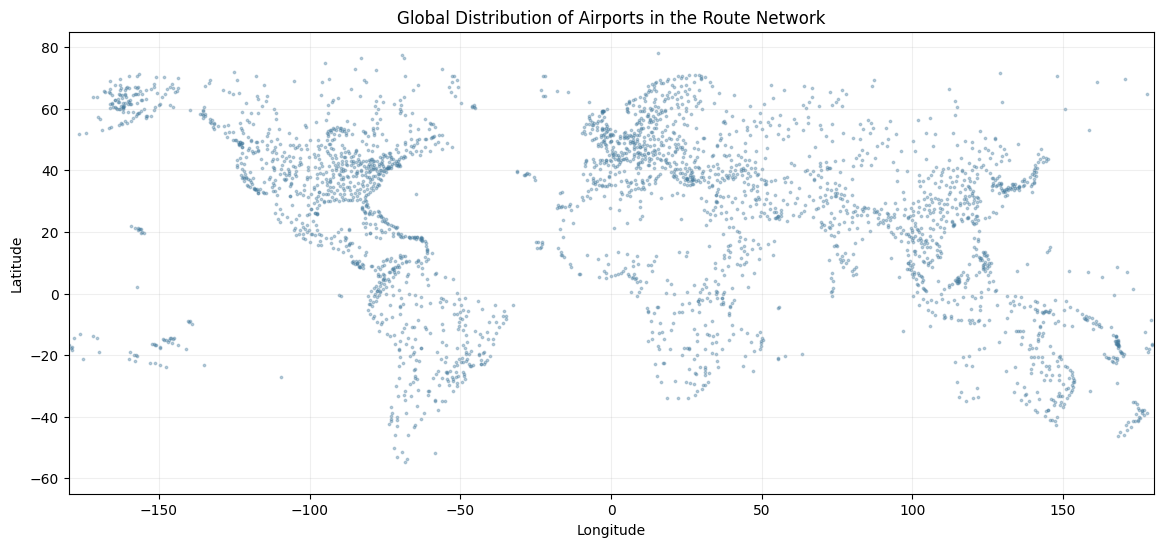

In [7]:
plt.figure(figsize=(14, 6))
plt.scatter(airport_map['longitude'], airport_map['latitude'], s=3, alpha=0.35, color='#457b9d')
plt.xlim(-180, 180)
plt.ylim(-65, 85)
plt.grid(alpha=0.2)
plt.title('Global Distribution of Airports in the Route Network')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## 2. Geographic distribution of hub airports

Marker size reflects total degree. Labels are shown only for the top 20 hubs so the figure remains readable.

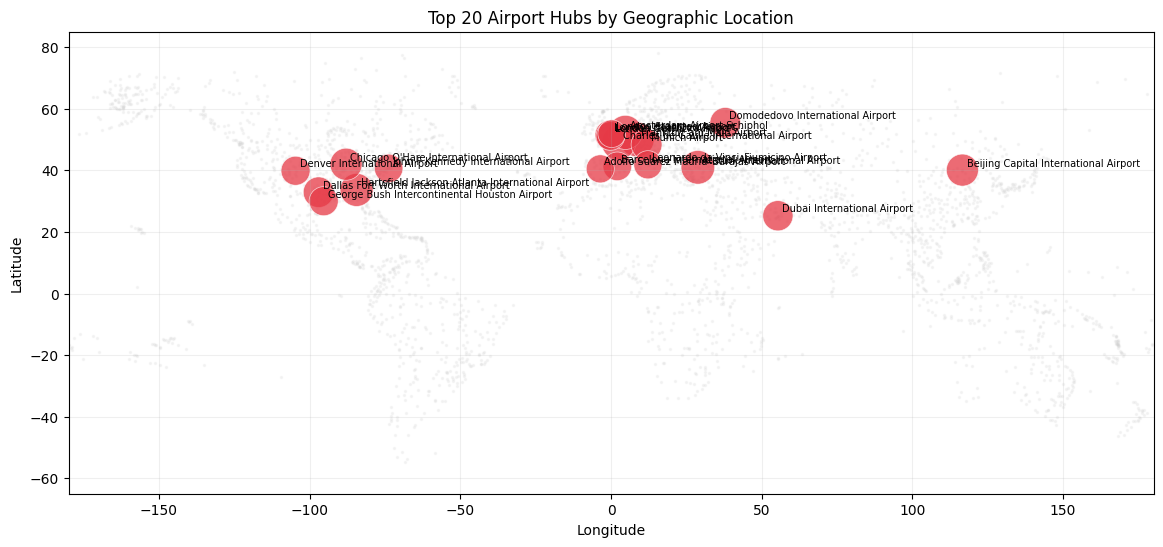

In [8]:
top_hubs = airport_map.nlargest(20, 'degree')

plt.figure(figsize=(14, 6))
plt.scatter(airport_map['longitude'], airport_map['latitude'], s=2, alpha=0.18, color='lightgray')
plt.scatter(top_hubs['longitude'], top_hubs['latitude'], s=top_hubs['degree'] * 1.3,
            alpha=0.75, color='#e63946', edgecolor='white', linewidth=0.5)
for _, airport in top_hubs.iterrows():
    plt.annotate(airport['name'], (airport['longitude'], airport['latitude']),
                 xytext=(3, 3), textcoords='offset points', fontsize=7)
plt.xlim(-180, 180)
plt.ylim(-65, 85)
plt.grid(alpha=0.2)
plt.title('Top 20 Airport Hubs by Geographic Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## Interpretation

The network covers every populated continent, but major hubs are concentrated in North America, Europe, East Asia, and the Middle East. This spatial imbalance helps explain the network's hub-and-spoke structure.